# Quantum Counting: Subset Sum Demonstration
This interactive notebook executes a fault-tolerant simulation of the subset sum oracle to find the number of valid solutions ($M$) using Quantum Phase Estimation.

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from src.counting import quantum_counting

weights = [1, 2, 3]
target = 3
precision = 6
shots = 100

print(f"Subset (S): {weights}")
print(f"Target (T): {target}")
print(f"Precision Qubits: {precision}")

Subset (S): [1, 2, 3]
Target (T): 3
Precision Qubits: 6


### Executing the Quantum Circuit
Because quantum mechanics is probabilistic, Phase Estimation is subject to **phase leakage**. We take multiple 'shots' of the circuit to observe the probability distribution and extract the mode.

In [3]:
results = []
print(f"Taking {shots} shots... (Simulating wave function collapse)\n")
for i in range(shots):
    m_estimated = quantum_counting(weights, target, precision_qubits=precision)
    results.append(m_estimated)
    
    if (i + 1) % 25 == 0:
        print(f"Completed {i + 1}/{shots} shots...")

counts = Counter(results)
mode = counts.most_common(1)[0][0]
print(f"\nMost frequent measurement (Mode): {mode}")

Taking 100 shots... (Simulating wave function collapse)

Completed 25/100 shots...
Completed 50/100 shots...
Completed 75/100 shots...
Completed 100/100 shots...

Most frequent measurement (Mode): 0


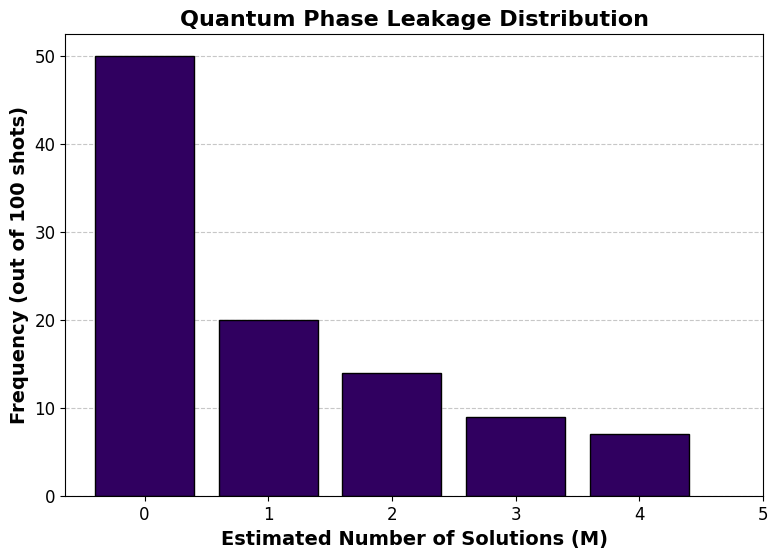

In [ ]:
%matplotlib inline

x_values = sorted(list(counts.keys()))
y_values = [counts[x] for x in x_values]

plt.figure(figsize=(9, 6))
plt.bar(x_values, y_values, color="#6D0AD0", edgecolor='black', zorder=2)
plt.xlabel('Estimated Number of Solutions (M)', fontsize=14, fontweight='bold')
plt.ylabel(f'Frequency (out of {shots} shots)', fontsize=14, fontweight='bold')
plt.title('Quantum Phase Leakage Distribution', fontsize=16, fontweight='bold')

if x_values:
    plt.xticks(range(min(0, min(x_values)), max(x_values) + 2), fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=1)

plt.show()